# Лабораторная работа №3. Валидационная выборка. Подбор гиперпараметров
________________________________________


Каждая НС имеет два вида параметров: изменяемые и неизменяемые.
1. в изменении первых от эпохи к эпохе заключается суть обучения, к ним относятся весовые коэффициенты.
2. гиперпараметры модели.

	К ним относятся:

    - количество слоев в модели;

    - типы слоев нейросети;

    - количество нейронов в каждом слое;

    - скорость обучения (learning rate);

    - размер мини-выборки при обучении (batch size);
    - функция ошибки ...

> [!info] Дополнение к теории: Гиперпараметры
> **Параметры** (веса и смещения) сеть *учит* сама в процессе градиентного спуска.
> **Гиперпараметры** мы *задаем вручную* до начала обучения. От их выбора зависит, сможет ли сеть вообще чему-то научиться и как быстро.
>
> *Дополнительные важные гиперпараметры, которые стоит знать:*
> * **Функция активации** (ReLU, Sigmoid, Tanh и др.).
> * **Коэффициент регуляризации** (L1, L2).
> * **Параметр Dropout** (доля отключаемых нейронов).
> * **Момент (Momentum)** в оптимизаторе.

## Переобучение (Overfitting)

Точность на обучающем наборе растет, а на проверочном до какой-то эпохи росла, а затем стала снижаться - момент начала переобучения НС.

### Причины
1. Малый размер данных.
2. Плохо собранная база.
3. Слишком сложная архитектура сети.
4. Разбалансировка базы.
5. Слишком много эпох обучения.

### Методы решения
1. Увеличение базы.
2. Чистка базы от выбросов, мусора (особенно актуально для текста).
3. Упрощение архитектуры (откат до минимально простой и постепенное усложнение).
4. Добавление слоев регуляризации `Dropout()` и нормализации `BatchNormalization()` из библиотеки Keras.
5. Аугментация, балансировка данных.
6. Отслеживание метрик по графикам, нахождение оптимального количества эпох

> [!tip] Важное дополнение: Early Stopping и Регуляризация
> В пункте 6 (отслеживание метрик) на практике редко делают вручную. Используют **Early Stopping** (Раннюю остановку) — это автоматическая остановка обучения, если метрика на валидации не улучшается N эпох подряд.
>
> ```python
> from tensorflow.keras.callbacks import EarlyStopping
> early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
> # Затем в model.fit(...) добавляют: callbacks=[early_stop]
> ```
> Также к методам решения (пункт 4) стоит добавить **L1/L2 регуляризацию** (штрафует сеть за слишком большие веса, заставляя ее быть проще).

---

## Практическая часть

### Библиотека и импорты

In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Activation
# Утилиты предобработки данных
from tensorflow.keras import utils
# Оптимизаторы
from tensorflow.keras.optimizers import Adam
# Разделение на обучающую и проверочную/тестовую выборку
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

%matplotlib inline

> [!note] Примечание по коду
>
> Команда %matplotlib inline — это "магическая" команда Jupyter Notebook / Google Colab. Она нужна для того, чтобы графики отрисовывались прямо в ячейке ноутбука, а не открывались в отдельном окне. В обычных .py скриптах она не используется.

# 1. Подготовка базы
##Загрузка и просмотр содержимого

In [4]:
df = pd.read_csv("sonar.csv", header=None)
print(df.shape)
df.head()

(208, 61)


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


В таблице 61 столбец: первые 60 описывают параметры объекта, последний 61-й содержит класс объекта (R – скала, M – мина).
Бинарная классификация.

In [5]:
dataset = df.replace('R', 1.).replace('M', 0.).astype(float).to_numpy()

/tmp/ipykernel_601/3864906435.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset = df.replace('R', 1.).replace('M', 0.).astype(float).to_numpy()


> [!warning] Важное уточнение по предобработке
>
> Нейронные сети плохо работают с данными разного масштаба. В датасете Sonar признаки имеют разные диапазоны значений. Перед подачей в сеть их необходимо нормализовать или стандартизировать!
Рекомендуется добавить этот шаг перед разделением на выборки:
>
> ```python
> from sklearn.preprocessing import StandardScaler
> scaler = StandardScaler()
> x_data = scaler.fit_transform(dataset[:, :60]) # Стандартизация признаков
> y_data = dataset[:, 60]
> ```

В x_data заносим параметры объекта, в y_data – класс объекта.

In [8]:
x_data = dataset[:, :60]
y_data = dataset[:, 60]

print('Размерность набора параметров объектов', x_data.shape)
print('Размерность набора меток класса', y_data.shape)
print()
print('Содержание y_data:', y_data)

Размерность набора параметров объектов (208, 60)
Размерность набора меток класса (208,)

Содержание y_data: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


**Создание обучающей и тестовой выборки**

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    x_data,        # параметры
    y_data,        # метки классов
    test_size=0.2, # процент в тестовую
    shuffle=True,  # перемешивание
    random_state=3 # воспроизводимость
)

print('Обучающая выборка параметров', x_train.shape)
print('Обучающая выборка меток классов', y_train.shape)
print()
print('Тестовая выборка параметров', x_test.shape)
print('Тестовая выборка меток классов', y_test.shape)

Обучающая выборка параметров (166, 60)
Обучающая выборка меток классов (166,)

Тестовая выборка параметров (42, 60)
Тестовая выборка меток классов (42,)


---
# 2. Обучение нейросети
Первый слой - 60 нейронов, 2 слой - 30 нейронов, и последний слой - 1 нейрон.
В выходном слое используем функцию активации sigmoid, (выход от 0 до 1).
binary_crossentropy - функции ошибки.

In [10]:
def create_model():
    # Создание модели
    model = Sequential()
    # Добавление слоев
    model.add(Dense(60, input_dim=x_train.shape[1], activation='relu'))
    model.add(Dense(30))
    model.add(Activation('relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Компиляция и возврат модели
    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics=['accuracy'])
    return model

# Создание модели
model = create_model()

# Обучение модели
history = model.fit(x_train,       # Обучающая выборка
                    y_train,       # Обучающая выборка меток класса
                    batch_size=8,  # Размер батча
                    epochs=100,    # Количество эпох обучения
                    verbose=1)     # Отображение обучения

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5904 - loss: 0.6882
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6506 - loss: 0.6621 
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6145 - loss: 0.6520 
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7048 - loss: 0.6310 
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7108 - loss: 0.6158 
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7048 - loss: 0.5933 
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7530 - loss: 0.5726 
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7169 - loss: 0.5628 
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7651 - loss: 0.5304 
Epoch 10/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7711 - loss: 0.5061 
Epoch 11/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8133 - loss: 0.4805 
Epoch 12/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0

>[!info] Теория: Почему именно такие функции?
>
> -    sigmoid на выходе и binary_crossentropy в качестве функции потерь — это золотой стандарт для задач бинарной классификации (0 или 1).
   >-  Если бы классов было больше (например, 3), на выходе стоял бы softmax, а функция ошибки была бы categorical_crossentropy.


   ---

# 3. Оценка качества обучения
Создание валидационной выборки.

In [11]:
# Создание необученной модели при помощи функции create_model()
model = create_model()

# Обучение нейронной сети
history = model.fit(x_train,               # Обучающая выборка параметров
                    y_train,               # Обучающая выборка меток класса
                    batch_size=8,          # Размер батча (пакета)
                    epochs=100,            # Количество эпох обучения
                    validation_split=0.2,  # Доля проверочной выборки
                    verbose=1)             # Отображение хода обучения

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5076 - loss: 0.6879 - val_accuracy: 0.7059 - val_loss: 0.6597
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6818 - loss: 0.6507 - val_accuracy: 0.6765 - val_loss: 0.6637
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6742 - loss: 0.6336 - val_accuracy: 0.6176 - val_loss: 0.6431
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7803 - loss: 0.6043 - val_accuracy: 0.6765 - val_loss: 0.6423
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7045 - loss: 0.5890 - val_accuracy: 0.6765 - val_loss: 0.5874
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7955 - loss: 0.5499 - val_accuracy: 0.6471 - val_loss: 0.6142
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8106 - loss: 0.5300 - val_accuracy: 0.7353 - val_loss: 0.5653
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7955 - loss: 0.5030 - val_accuracy: 0.7353 - 

 >   [!warning] Внимание: validation_split vs test_set
 > -   Параметр validation_split=0.2 "откусывает" 20% от обучающей выборки (x_train) прямо во время обучения для проверки на каждой эпохе.
 > -   А x_test — это тестовая выборка, которую сеть вообще не видела во время обучения. Она нужна для финальной, объективной оценки.

**Посмотреть точность на проверочной выборке**
Применим метод .evaluate() к модели, параметры -- тестовые выборки. Поместим результат в переменную scores:

In [12]:
scores = model.evaluate(x_test,
                        y_test,
                        verbose=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8095 - loss: 0.4125


---

# 4. Визуализация качества обучения
Строим график точности на протяжении всего обучения.

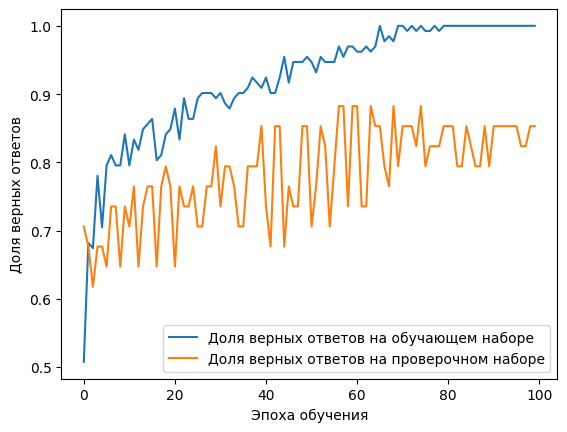

In [13]:
# Визуализация точности на обучающей выборке
plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
# Визуализация точности на проверочной выборке
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
# Отрисовка подписей осей
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
# Отрисовка легенды
plt.legend()
# Вывод графика
plt.show()

Вывод графика ошибки:

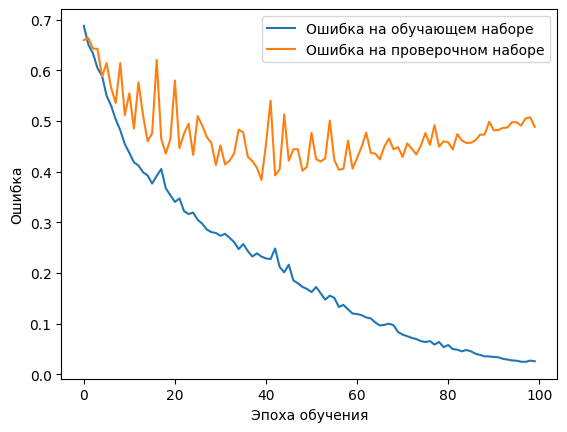

In [14]:
plt.plot(history.history['loss'],
         label='Ошибка на обучающем наборе')
plt.plot(history.history['val_loss'],
         label='Ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

Если ошибка на обучающей выборке стремится к 0, а на проверочной выборке снижается, а потом снова растет – это эффект переобучения.

---

# 5. Слой Dropout
Возьмите исходную архитектуру НС и добавьте слои Dropout:

In [15]:
# Создание последовательной модели
model = Sequential()
model.add(Dropout(0.3, input_shape=(x_train.shape[1],)))
model.add(Dense(60, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(30, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

# Компиляция модели
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Обучение сети
history = model.fit(x_train,
                    y_train,
                    batch_size=8,
                    epochs=200,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/200


/usr/local/lib/python3.13/dist-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4015 - loss: 0.7415 - val_accuracy: 0.7059 - val_loss: 0.6401
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5379 - loss: 0.6913 - val_accuracy: 0.7353 - val_loss: 0.6687
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4167 - loss: 0.7302 - val_accuracy: 0.7647 - val_loss: 0.6745
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5152 - loss: 0.7040 - val_accuracy: 0.7941 - val_loss: 0.6540
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5152 - loss: 0.7044 - val_accuracy: 0.8235 - val_loss: 0.6603
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5455 - loss: 0.6901 - val_accuracy: 0.8235 - val_loss: 0.6515
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5303 - loss: 0.7054 - val_accuracy: 0.5000 - val_loss: 0.6890
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5833 - loss: 0.6669 - val_accuracy: 0.6176 - val_los

Результаты показывают, что после 200 эпох точность на обучающей выборке остановилось на 85%. Переобучения нет.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,565 (64.71 KB)

 Trainable params: 5,521 (21.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,044 (43.14 KB)

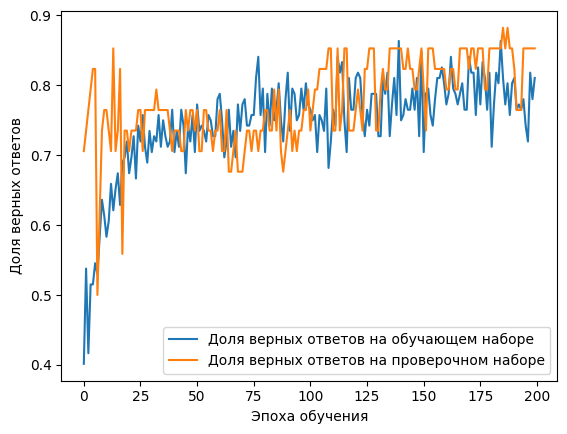

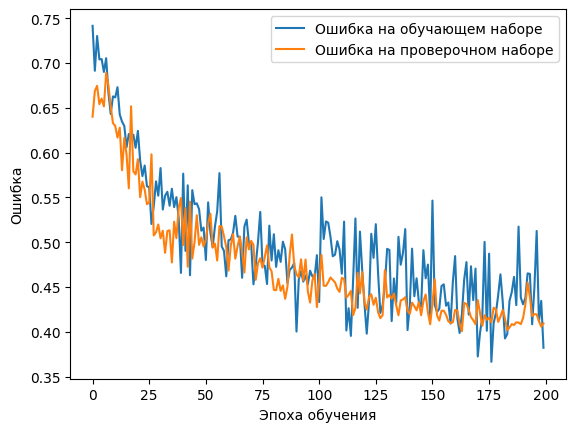

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8810 - loss: 0.3759
[0.3759264349937439, 0.8809523582458496]
Доля верных ответов на тестовых данных, в процентах: 88.0952%


In [16]:
# Краткая сводка архитектуры модели
model.summary()

# Отрисовка графика точности на обучающей выборке
plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

# Вывод графика ошибки
plt.plot(history.history['loss'],
         label='Ошибка на обучающем наборе')
plt.plot(history.history['val_loss'],
         label='Ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

# Вычисление результата (предсказания) сети на тестовом наборе
scores = model.evaluate(x_test, y_test, verbose=1)
print(scores)
print('Доля верных ответов на тестовых данных, в процентах: {:7.4%}'.format(scores[1]))

---

# 6. Слой BatchNormalization
Изменим архитектуру сети, добавим слой BatchNormalization.

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4394 - loss: 0.8584 - val_accuracy: 0.3235 - val_loss: 0.7179
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4697 - loss: 0.8055 - val_accuracy: 0.2647 - val_loss: 0.7111
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5303 - loss: 0.7568 - val_accuracy: 0.3235 - val_loss: 0.7045
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.5530 - loss: 0.7115 - val_accuracy: 0.3824 - val_loss: 0.6984
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5682 - loss: 0.6704 - val_accuracy: 0.5882 - val_loss: 0.6927
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6439 - loss: 0.6327 - val_accuracy: 0.6471 - val_loss: 0.6873
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7045 - loss: 0.5987 - val_accuracy: 0.7059 - val_loss: 0.6822
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7424 - loss: 0.5687 - val_accuracy: 0.7353 - val_loss: 0.6773
Epoch

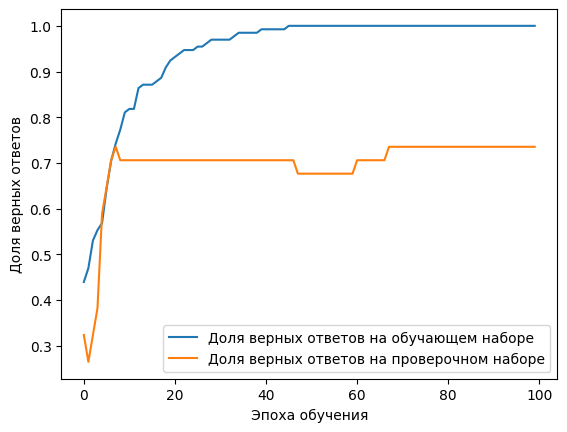

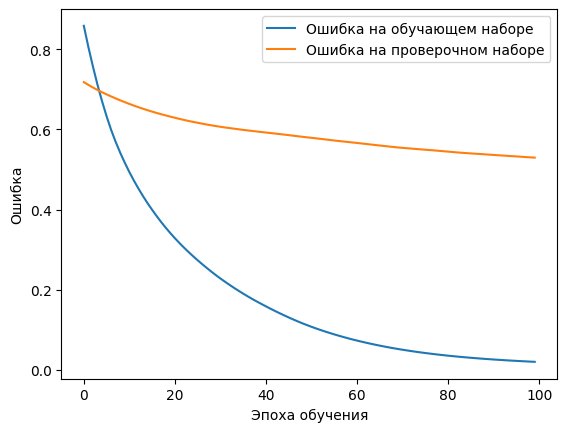

In [17]:
model = Sequential()
model.add(BatchNormalization(input_shape=(x_train.shape[1], )))
model.add(Dense(60, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(30, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

history = model.fit(x_train,
                    y_train,
                    batch_size=200, # Обратите внимание: размер батча увеличен!
                    epochs=100,
                    validation_split=0.2,
                    verbose=1)

plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

plt.plot(history.history['loss'],
         label='Ошибка на обучающем наборе')
plt.plot(history.history['val_loss'],
         label='Ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

> [!warning] Важное замечание по BatchNormalization
>
> 1. Зачем нужен: BatchNormalization нормализует входы каждого слоя (приводит к среднему 0 и дисперсии 1). Это решает проблему "исчезающих градиентов", позволяет обучать более глубокие сети и использовать бóльшие скорости обучения (learning rate).
> 2. Почему batch_size=200? BatchNorm вычисляет среднее и дисперсию внутри текущего батча. Если батч слишком маленький (как batch_size=8 в предыдущих примерах), статистика будет "шумной" и нестабильной, что ухудшит обучение. Для BatchNorm рекомендуется брать batch_size побольше (32, 64, 128, 256).